In [10]:
import pandas as pd

# Load the supermarket sales dataset
df = pd.read_csv("supermarket_sales.csv")  # Replace with your path if needed

# Display first few rows
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [11]:
# Show column names
df.columns

# Basic info (data types, missing values)
df.info()

# Statistical summary
df.describe()

# Number of rows & columns
df.shape

# Check unique values in important columns
df['Product line'].unique()
df['Payment'].unique()
df['City'].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

array(['Yangon', 'Naypyitaw', 'Mandalay'], dtype=object)

In [12]:
#Total Sales by Product Line
sales_by_product = df.groupby("Product line")["Total"].sum()
sales_by_product

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64

In [13]:
#Total Sales by Payment Method
sales_by_payment = df.groupby("Payment")["Total"].sum()
sales_by_payment

Payment
Cash           112206.570
Credit card    100767.072
Ewallet        109993.107
Name: Total, dtype: float64

In [14]:
#Total Sales by City
sales_by_city = df.groupby("City")["Total"].sum()
sales_by_city

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Total, dtype: float64

In [15]:
#Average Rating per Product Line
rating_by_product = df.groupby("Product line")["Rating"].mean()
rating_by_product

Product line
Electronic accessories    6.924706
Fashion accessories       7.029213
Food and beverages        7.113218
Health and beauty         7.003289
Home and lifestyle        6.837500
Sports and travel         6.916265
Name: Rating, dtype: float64

In [16]:
#Quantity Sold by Product Line
quantity_by_product = df.groupby("Product line")["Quantity"].sum()
quantity_by_product

Product line
Electronic accessories    971
Fashion accessories       902
Food and beverages        952
Health and beauty         854
Home and lifestyle        911
Sports and travel         920
Name: Quantity, dtype: int64

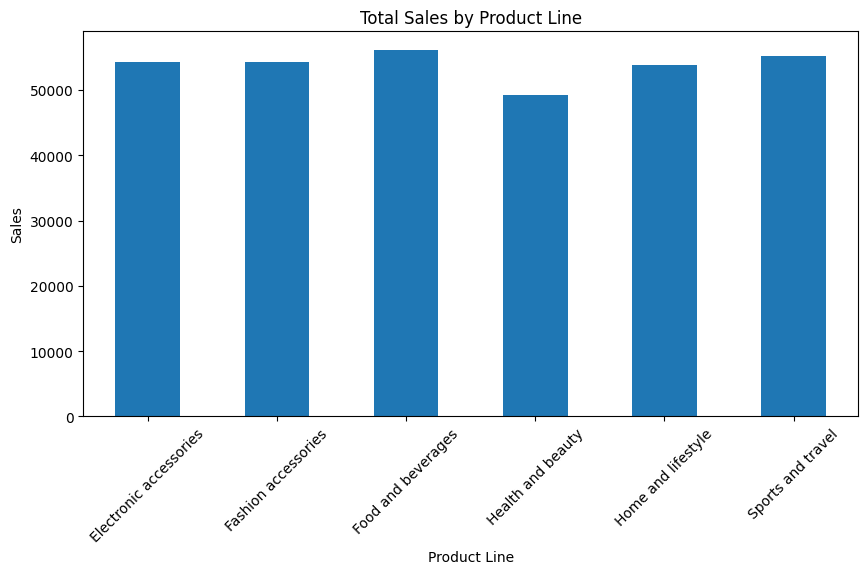

In [17]:
#Visualization

import matplotlib.pyplot as plt

# -----------------------------
# 1. Bar chart: Sales by Product Line
# -----------------------------
plt.figure(figsize=(10,5))
sales_by_product.plot(kind='bar')
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

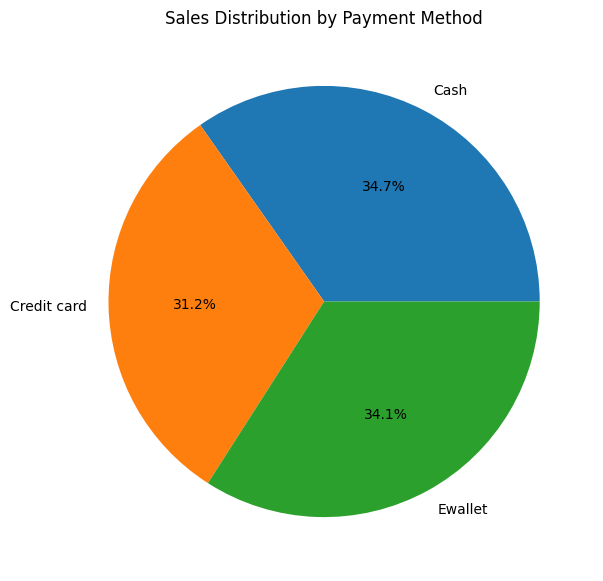

In [18]:
# 2. Pie Chart: Payment Methods Share
plt.figure(figsize=(7,7))
sales_by_payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Payment Method")
plt.ylabel("")
plt.show()

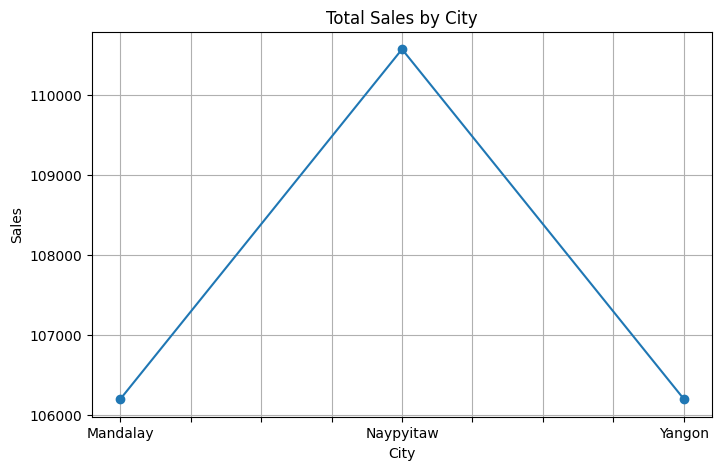

In [20]:
# 3. Line Chart: Total Sales by City
plt.figure(figsize=(8,5))
sales_by_city.plot(kind='line', marker='o')
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

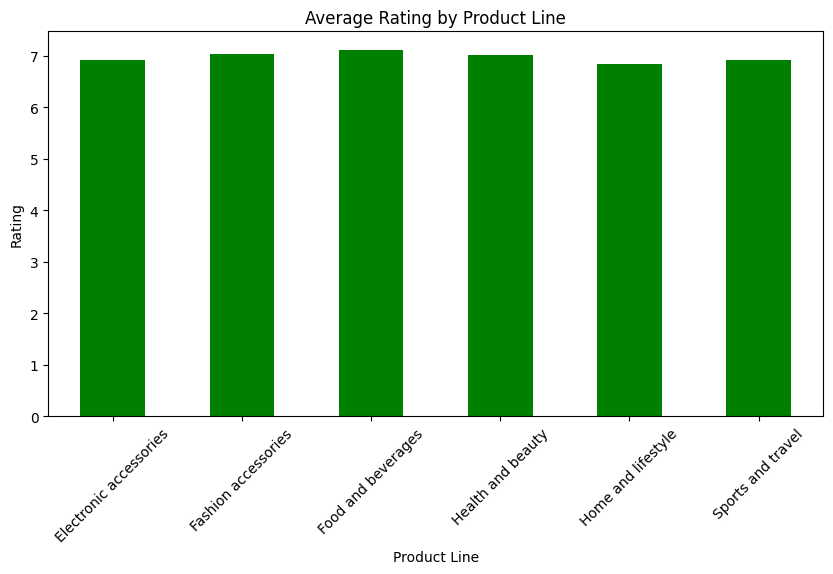

In [21]:
# 4. Bar chart: Average Rating by Product Line
plt.figure(figsize=(10,5))
rating_by_product.plot(kind='bar', color='green')
plt.title("Average Rating by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()

In [22]:
#Highest rated product line
df.groupby("Product line")["Rating"].mean().sort_values(ascending=False).head(1)

Product line
Food and beverages    7.113218
Name: Rating, dtype: float64

In [23]:
#Branch with highest revenue
df.groupby("Branch")["Total"].sum().sort_values(ascending=False)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64